## Grid Search Hyperparameter optimization

This case study is all about using grid searches to identify the optimal parameters for a machine learning algorithm. To complere this case study, you'll use the Pima Indian diabetes dataset from Kaggle and KNN. Follow along with the preprocessing steps of this case study.

Load the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# set random seed to try make this exercise and solutions reproducible (NB: this is just for teaching purpose and not something you would do in real life)
random_seed_number = 42
np.random.seed(random_seed_number)

#### Load the diabetes data

In [2]:
diabetes_data = pd.read_csv('data/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**<font color='teal'> Start by reviewing the data info.</font>**

In [3]:
# Review the structure of the dataset, including
# column names, data types, and missing values.

diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**<font color='teal'> Apply the describe function to the data.</font>**

In [4]:
# Generate descriptive statistics for the dataset
# to better understand the distribution of each feature.

diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**<font color='teal'> Currently, the missing values in the dataset are represented as zeros. Replace the zero values in the following columns ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] with nan .</font>**

In [5]:
# Replace biologically impossible zero values with NaN
# in the specified medical measurement columns.

columns_with_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

diabetes_data[columns_with_missing] = diabetes_data[columns_with_missing].replace(0, np.nan)

# Verify the changes
diabetes_data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

**<font color='teal'> Plot histograms of each column. </font>**

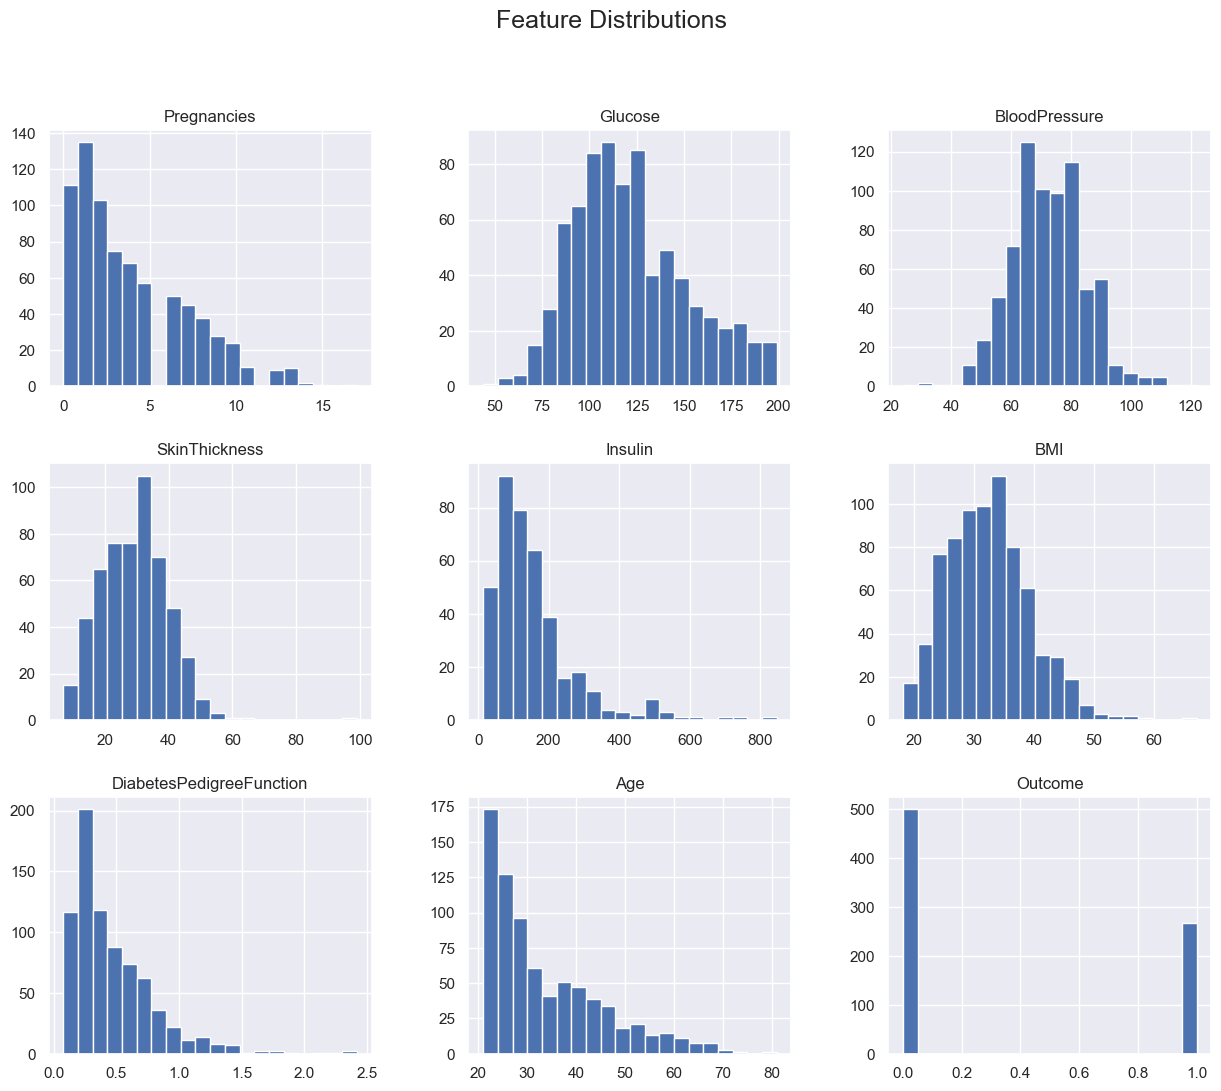

In [6]:
# Plot histograms for all columns in the dataset
# to visualize the distributions of each feature.

diabetes_data.hist(figsize=(15,12), bins=20)

plt.suptitle('Feature Distributions', fontsize=18)

plt.show()

#### Replace the zeros with mean and median values.

In [7]:
# Replace missing values using mean and median imputation
# without chained assignment warnings.

diabetes_data['Glucose'] = diabetes_data['Glucose'].fillna(
    diabetes_data['Glucose'].mean()
)

diabetes_data['BloodPressure'] = diabetes_data['BloodPressure'].fillna(
    diabetes_data['BloodPressure'].mean()
)

diabetes_data['SkinThickness'] = diabetes_data['SkinThickness'].fillna(
    diabetes_data['SkinThickness'].median()
)

diabetes_data['Insulin'] = diabetes_data['Insulin'].fillna(
    diabetes_data['Insulin'].median()
)

diabetes_data['BMI'] = diabetes_data['BMI'].fillna(
    diabetes_data['BMI'].median()
)

**<font color='teal'> Plot histograms of each column after replacing nan. </font>**

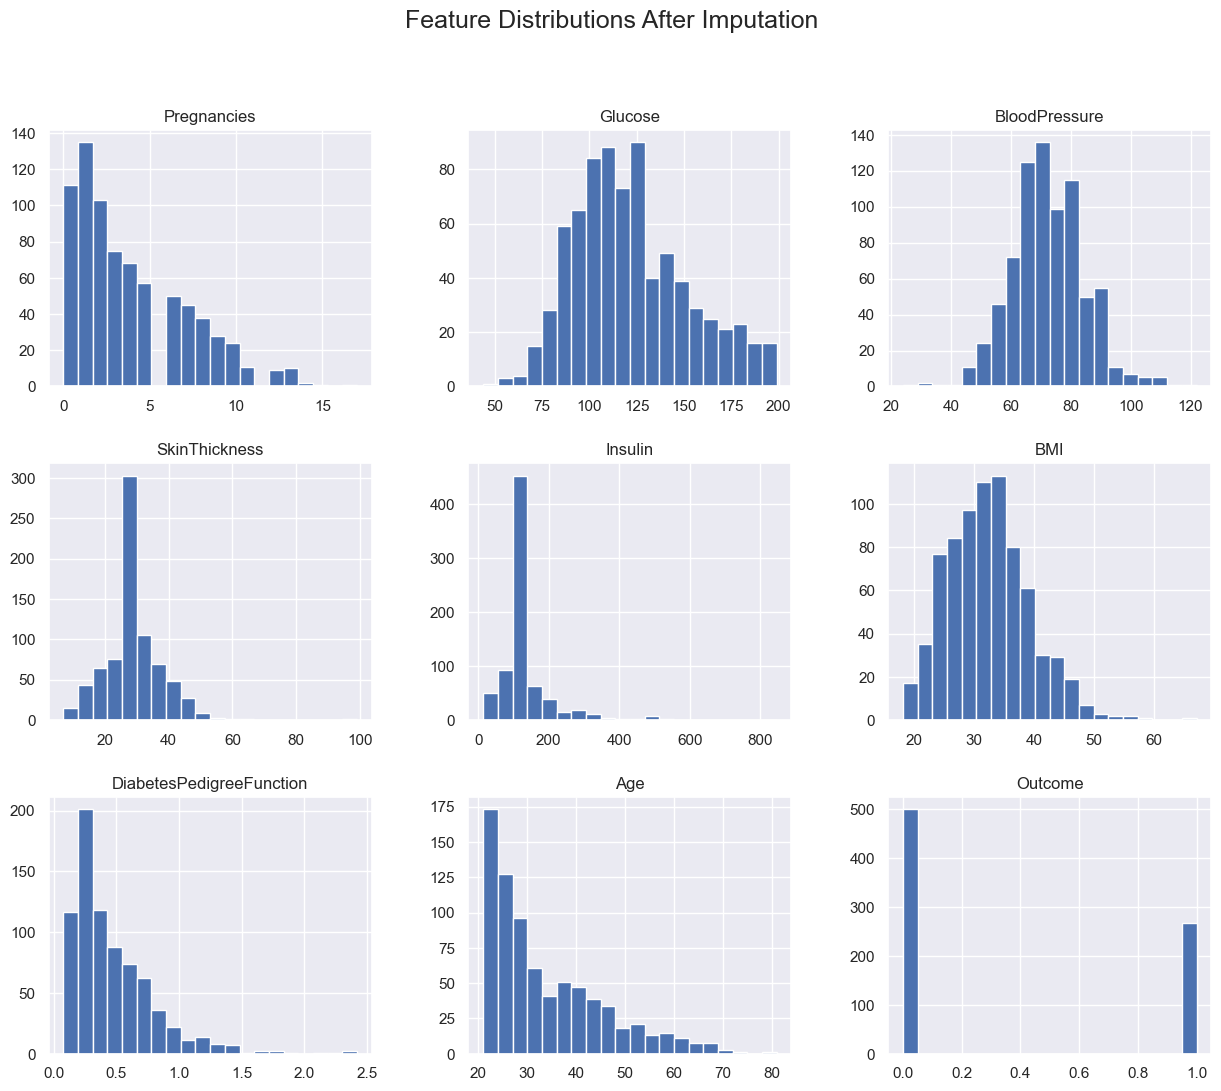

In [8]:
# Plot histograms after replacing missing values
# with mean and median imputation values.

diabetes_data.hist(figsize=(15,12), bins=20)

plt.suptitle('Feature Distributions After Imputation', fontsize=18)

plt.show()

#### Plot the correlation matrix heatmap

Correlation between various features


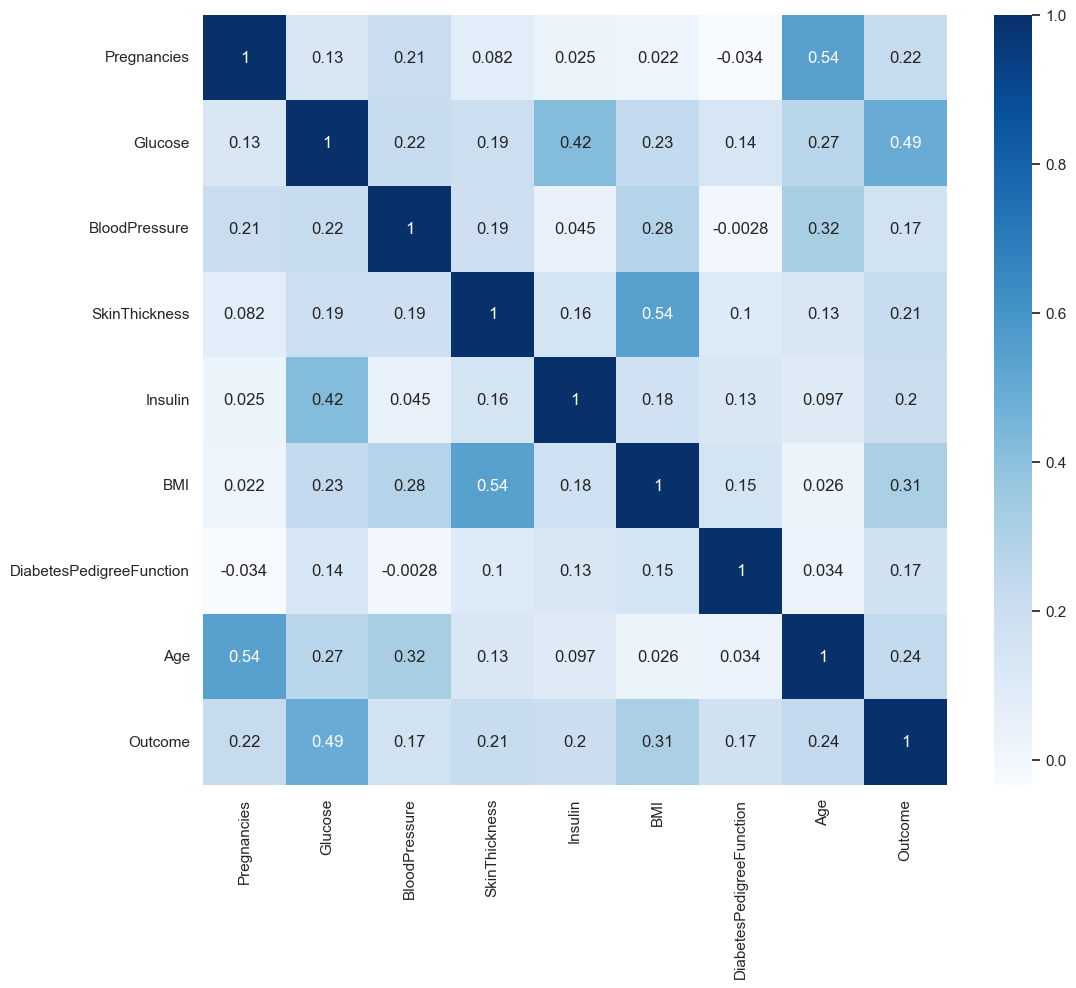

In [9]:
plt.figure(figsize=(12,10))
print('Correlation between various features')
p=sns.heatmap(diabetes_data.corr(), annot=True,cmap ='Blues')

**<font color='teal'> Define the `y` variable as the `Outcome` column.</font>**

In [10]:
# Define the target variable (y) using the Outcome column.

y = diabetes_data['Outcome']

# Display the first few values
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

**<font color='teal'> Create a 70/30 train and test split. </font>**

In [11]:
# Create feature matrix X and target vector y,
# then split the dataset into 70% training data
# and 30% testing data.

from sklearn.model_selection import train_test_split

# Define feature matrix
X = diabetes_data.drop('Outcome', axis=1)

# Define target variable
y = diabetes_data['Outcome']

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Display the shapes of the split datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)


**<font color='teal'> Using Sklearn, standarize the magnitude of the features by scaling the values. </font>**

Note: Don't forget to fit() your scaler on X_train and then use that fitted scaler to transform() X_test. This is to avoid data leakage while you standardize your data.

In [12]:
# Standardize the feature variables so they have
# a mean of 0 and a standard deviation of 1.
# Fit the scaler only on the training data to avoid data leakage.

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
scaler.fit(X_train)

# Transform training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few scaled training rows
X_train_scaled[:5]

array([[-0.8362943 , -0.89610788, -1.00440048, -1.26954457, -0.956993  ,
        -1.20382556, -0.61421636, -0.94861028],
       [ 0.39072767, -0.56399695, -0.02026586,  0.02969309,  2.13679743,
         0.66449801, -0.90973787, -0.43466673],
       [-1.14304979,  0.43233584, -0.34831073,  1.56515578,  1.26775517,
         1.44057087, -0.30699103, -0.77729576],
       [ 0.08397217,  0.29949146, -0.34831073, -0.91520703,  0.29442785,
         0.11837266, -0.90681191, -0.43466673],
       [-0.8362943 , -0.63041914, -3.46473705,  1.09270572, -0.66731225,
         1.58428807, -0.83951493, -0.00638043]])

#### Using a range of neighbor values of 1-10, apply the KNearestNeighbor classifier to classify the the data.

In [13]:
# Train KNN classifiers using neighbor values from 1 to 10
# and store training and testing accuracy scores.

from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []

for i in range(1, 11):

    # Initialize KNN model
    knn = KNeighborsClassifier(n_neighbors=i)

    # Fit model using scaled training data
    knn.fit(X_train_scaled, y_train)

    # Store accuracy scores
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

**<font color='teal'> Print the train and test scores for each iteration.</font>**

In [14]:
# Print the training and testing accuracy scores
# for each K value from 1 to 10.

for i in range(1, 11):
    print(f"K = {i}")
    print(f"Train Score: {train_scores[i-1]:.4f}")
    print(f"Test Score: {test_scores[i-1]:.4f}")
    print("-" * 30)

K = 1
Train Score: 1.0000
Test Score: 0.6667
------------------------------
K = 2
Train Score: 0.8510
Test Score: 0.6710
------------------------------
K = 3
Train Score: 0.8547
Test Score: 0.6710
------------------------------
K = 4
Train Score: 0.8417
Test Score: 0.6926
------------------------------
K = 5
Train Score: 0.8399
Test Score: 0.7013
------------------------------
K = 6
Train Score: 0.8231
Test Score: 0.6840
------------------------------
K = 7
Train Score: 0.8343
Test Score: 0.7316
------------------------------
K = 8
Train Score: 0.8212
Test Score: 0.7359
------------------------------
K = 9
Train Score: 0.8268
Test Score: 0.7316
------------------------------
K = 10
Train Score: 0.8175
Test Score: 0.7186
------------------------------


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the training dataset. </font>**

In [15]:
# Identify the K value that produced the highest
# training accuracy score.

max_train_score = max(train_scores)

best_k_train = train_scores.index(max_train_score) + 1

print("Best K for Training Data:", best_k_train)
print("Highest Training Score:", max_train_score)

Best K for Training Data: 1
Highest Training Score: 1.0


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the testing dataset. </font>**

In [16]:
# Identify the K value that produced the highest
# testing accuracy score.

max_test_score = max(test_scores)

best_k_test = test_scores.index(max_test_score) + 1

print("Best K for Testing Data:", best_k_test)
print("Highest Testing Score:", max_test_score)

Best K for Testing Data: 8
Highest Testing Score: 0.7359307359307359


Plot the train and test model performance by number of neighbors.

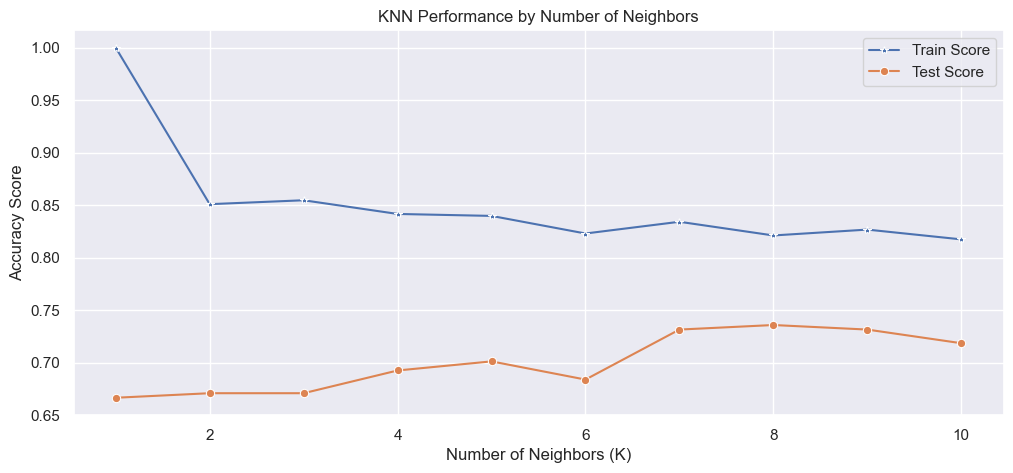

In [17]:
# Plot training and testing accuracy scores
# for different values of K.

plt.figure(figsize=(12,5))

sns.lineplot(
    x=range(1, 11),
    y=train_scores,
    marker='*',
    label='Train Score'
)

sns.lineplot(
    x=range(1, 11),
    y=test_scores,
    marker='o',
    label='Test Score'
)

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('KNN Performance by Number of Neighbors')

plt.show()

**<font color='teal'> Fit and score the best number of neighbors based on the plot. </font>**

In [18]:
# Fit a final KNN model using the best number of neighbors
# identified from the testing accuracy scores.

best_k = 8

# Initialize the final KNN model
knn = KNeighborsClassifier(n_neighbors=best_k)

# Fit the model using scaled training data
knn.fit(X_train_scaled, y_train)

# Calculate and print scores
train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)

print("Best K:", best_k)
print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Best K: 8
Training Accuracy: 0.8212290502793296
Testing Accuracy: 0.7359307359307359


In [19]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
pl = confusion_matrix(y_test,y_pred)

C:\Users\hillk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


**<font color='teal'> Plot the confusion matrix for the model fit above. </font>**

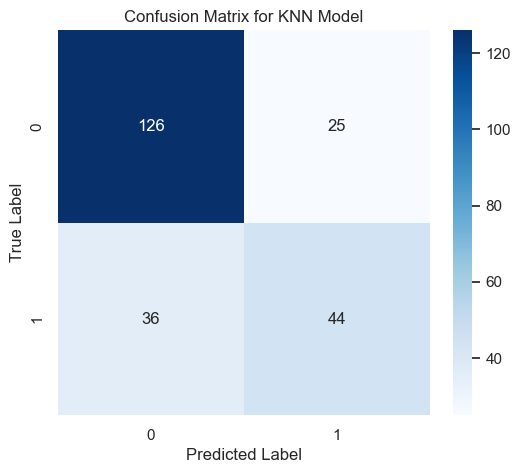

In [20]:
# Generate predictions using the scaled test data
# and plot the confusion matrix for the final KNN model.

from sklearn.metrics import confusion_matrix

# Generate predictions
y_pred = knn.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Model')

plt.show()

**<font color='teal'> Print the classification report </font>**

In [21]:
# Print the classification report for the final KNN model.

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       151
           1       0.64      0.55      0.59        80

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



#### In the case of the K nearest neighbors algorithm, the K parameter is one of the most important parameters affecting the model performance.  The model performance isn't horrible, but what if we didn't consider a wide enough range of values in our neighbors for the KNN? An alternative to fitting a loop of models is to use a grid search to identify the proper number. It is common practice to use a grid search method for all adjustable parameters in any type of machine learning algorithm. First, you define the grid — aka the range of values — to test in the parameter being optimized, and then compare the model outcome performance based on the different values in the grid.

#### Run the code in the next cell to see how to implement the grid search method for identifying the best parameter value for the n_neighbors parameter. Notice the param_grid is the range value to test and we apply cross validation with five folds to score each possible value of n_neighbors.

In [22]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

#### Print the best score and best parameter for n_neighbors.

In [23]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7526440879382056
Best Parameters: {'n_neighbors': np.int64(31)}


**<font color='teal'> Now, following the KNN example, apply this grid search method to find the optimal number of estimators in a Randon Forest model.
</font>**

In [24]:
# Apply GridSearchCV to identify the optimal number
# of estimators for a Random Forest classifier.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': np.arange(10, 201, 10)
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Apply GridSearchCV with 5-fold cross-validation
rf_cv = GridSearchCV(
    rf,
    param_grid,
    cv=5
)

# Fit the model
rf_cv.fit(X, y)

# Print best score and best parameter
print("Best Score:", rf_cv.best_score_)
print("Best Parameters:", rf_cv.best_params_)

Best Score: 0.7708853238265003
Best Parameters: {'n_estimators': np.int64(30)}
